# Cycling Crash Severity and Spatial Inequalities — analysis notebook

**Cell A** — exposure-normalised crash rates (Table 5.1, Figures 5.4–5.6)

**Cell B** — severity classification (Tables 5.2–5.4, Figures 5.7–5.12)

Both cells expect the input files in the working directory. Edit the paths at the top of Cell A if yours differ.

Outputs written to disk:

- `greater_london_exposure_normalised_rate.png`, `greater_manchester_...`, `west_midlands_...`
- `table_5_1_exposure_normalised_rates.csv`
- `greater_london_roc.png`, `greater_manchester_roc.png`, `west_midlands_roc.png`
- `greater_london_shap_bar_lightgbm.png`, `..._beeswarm_lightgbm.png`, `..._dependence_sex_lightgbm.png`
- `tables_5_2_to_5_4_model_performance.csv`


IMD 2019: 32,844 LSOAs, 317 local authorities
Cycling commuters: 34,753 LSOAs, 556,286 commuters nationally

===== Greater London
  33 local authorities, 4,835 LSOAs, 125,551 cycling commuters
  casualties: 9,660 recorded in region, 7,857 resident in region (18.7% excluded)
 decile  n_lsoa  commuters  crashes  rate
      1     107       2836      196 34.56
      2     688      18813     1270 33.75
      3     811      24645     1567 31.79
      4     661      21332     1245 29.18
      5     559      15739     1036 32.91
      6     532      13519      826 30.55
      7     438       9561      596 31.17
      8     413       8443      474 28.07
      9     407       7142      413 28.91
     10     219       3521      234 33.23
  D1 = 34.6   D10 = 33.2   D10/D1 = 0.96x
  Spearman(decile, rate) = -0.539  p = 0.108


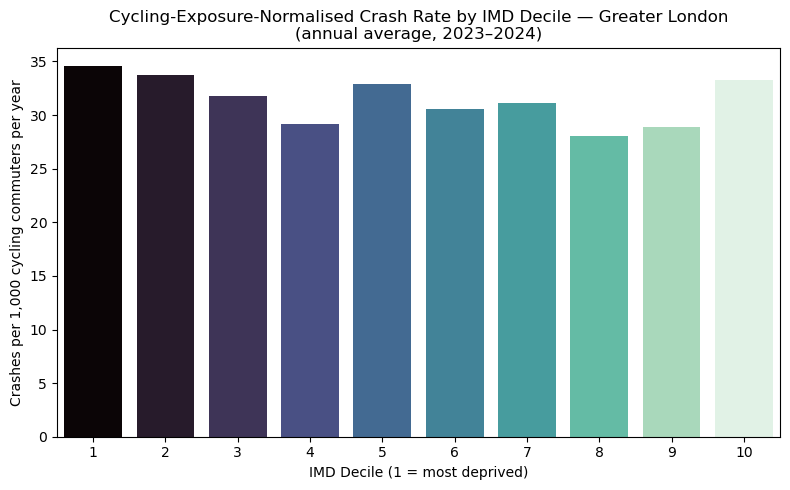


===== Greater Manchester
  10 local authorities, 1,673 LSOAs, 20,929 cycling commuters
  casualties: 914 recorded in region, 672 resident in region (26.5% excluded)
 decile  n_lsoa  commuters  crashes  rate
      1     390       5537      166 14.99
      2     244       3076       95 15.44
      3     194       2943       84 14.27
      4     150       2489       71 14.26
      5     130       1542       51 16.54
      6     111       1470       42 14.29
      7     120       1172       51 21.76
      8     128       1086       52 23.94
      9     115        903       32 17.72
     10      91        711       28 19.69
  D1 = 15.0   D10 = 19.7   D10/D1 = 1.31x
  Spearman(decile, rate) = +0.673  p = 0.033


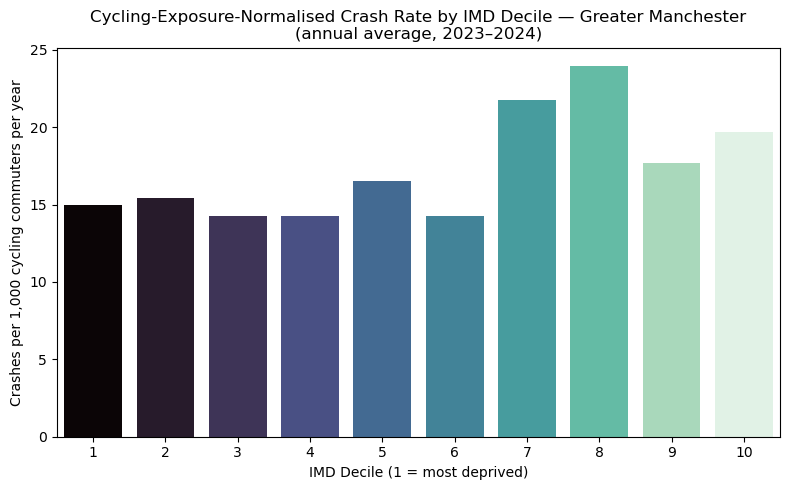


===== West Midlands
  7 local authorities, 1,680 LSOAs, 15,387 cycling commuters
  casualties: 880 recorded in region, 681 resident in region (22.6% excluded)
 decile  n_lsoa  commuters  crashes  rate
      1     444       4212      218 25.88
      2     313       3129      138 22.05
      3     190       1965       91 23.16
      4     153       1554       74 23.81
      5     146       1479       56 18.93
      6     104        963       30 15.58
      7      94        735       22 14.97
      8      83        555       18 16.22
      9      73        403       16 19.85
     10      80        392       18 22.96
  D1 = 25.9   D10 = 23.0   D10/D1 = 0.89x
  Spearman(decile, rate) = -0.515  p = 0.128


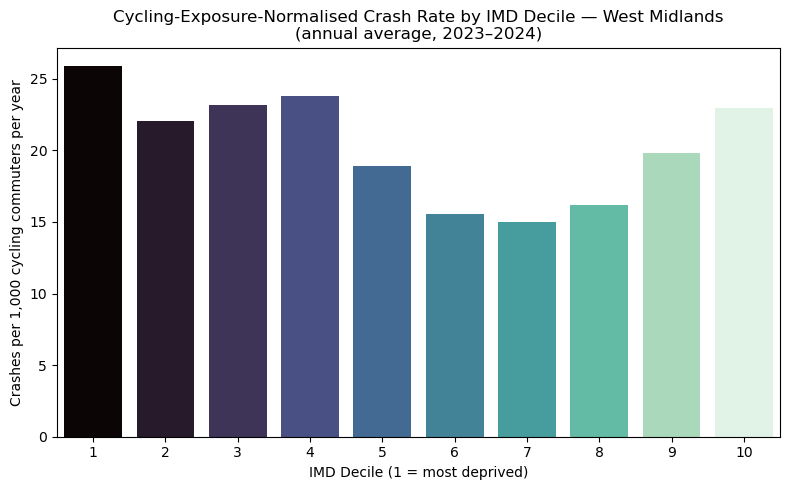



========== Table 5.1 ==========
region  Greater London  Greater Manchester  West Midlands
decile                                                   
1                 34.6                15.0           25.9
2                 33.8                15.4           22.1
3                 31.8                14.3           23.2
4                 29.2                14.3           23.8
5                 32.9                16.5           18.9
6                 30.5                14.3           15.6
7                 31.2                21.8           15.0
8                 28.1                23.9           16.2
9                 28.9                17.7           19.9
10                33.2                19.7           23.0


In [1]:
"""
Cell A — Exposure-normalised crash rate analysis (corrected)
============================================================
Produces Table 5.1 and Figures 5.4-5.6.

Denominator : total Census 2021 cycling commuters across EVERY LSOA in the study
              region assigned to a given IMD decile, including LSOAs in which no
              casualty was recorded.
Numerator   : casualties whose RESIDENTIAL LSOA lies inside the study region and
              is assigned to that decile, so that numerator and denominator
              describe the same population. IMD deciles are national, not
              region-internal, so without this restriction a region-only
              denominator is paired with a partly national numerator.
Region       : derived from the data — each casualty's crash-location LSOA is
              matched to its 2019 Local Authority District and the region is the
              full set of districts so identified.

Required input files (edit the paths below if yours differ):
  IMD_FILE     File 7 / File 1 of the English Indices of Deprivation 2019
  TRAVEL_FILE  ONS Census 2021 TS061, LSOA level
  LOOKUP_FILE  ONS Best Fit LSOA(2011) -> LSOA(2021)
  the three regional casualty point files
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# ---------------------------------------------------------------- configuration
IMD_FILE    = 'File_1_-_IMD2019_Index_of_Multiple_Deprivation.xlsx'
IMD_SHEET   = 'IMD2019'
TRAVEL_FILE = 'TS061-2021-6-filtered-2026-07-14T22-52-50Z.csv'
LOOKUP_FILE = 'lsoa11_to_lsoa21_lookup.csv'

REGION_FILES = {
    'Greater London':     'london_point.csv',
    'Greater Manchester': 'manchester_point.csv',
    'West Midlands':      'birmingham_point.csv',
}

N_YEARS = 2          # 2023-2024

# --------------------------------------------- 1. IMD: LSOA(2011) -> decile, LAD
imd = pd.read_excel(IMD_FILE, sheet_name=IMD_SHEET).rename(columns={
    'LSOA code (2011)': 'lsoa11',
    'Local Authority District name (2019)': 'lad',
    'Index of Multiple Deprivation (IMD) Decile': 'decile',
})[['lsoa11', 'lad', 'decile']]
print(f'IMD 2019: {len(imd):,} LSOAs, {imd["lad"].nunique()} local authorities')

# ------------------------------------ 2. Cycling commuters per 2011 LSOA
travel = pd.read_csv(TRAVEL_FILE)
GEOG, CAT, VAL = ('Lower layer Super Output Areas Code',
                  'Method used to travel to workplace (12 categories)',
                  'Observation')
cycling = (travel[travel[CAT].astype(str).str.strip().eq('Bicycle')][[GEOG, VAL]]
           .rename(columns={GEOG: 'LSOA21CD', VAL: 'commuters'}))

lookup = pd.read_csv(LOOKUP_FILE)
lookup.columns = [c.lstrip('﻿') for c in lookup.columns]   # strip BOM

# One row per 2011 LSOA. Where a 2011 LSOA was split into several 2021 LSOAs the
# commuter counts are summed back together, so joining this table onto casualty
# records cannot duplicate rows.
commuters = (lookup[['LSOA11CD', 'LSOA21CD']].drop_duplicates()
             .merge(cycling, how='left', on='LSOA21CD')
             .groupby('LSOA11CD', as_index=False)['commuters'].sum()
             .rename(columns={'LSOA11CD': 'lsoa11'}))
commuters['commuters'] = commuters['commuters'].fillna(0)
print(f'Cycling commuters: {len(commuters):,} LSOAs, '
      f'{commuters["commuters"].sum():,.0f} commuters nationally')

# ------------------------------------------------ 3. Per region: rate by decile
results, tables = {}, []

for region, path in REGION_FILES.items():
    crashes = pd.read_csv(path, low_memory=False)

    # -- region extent, derived from the crash-location LSOAs themselves --------
    lads = sorted(crashes.merge(imd, how='left',
                                left_on='lsoa_of_accident_location',
                                right_on='lsoa11')['lad'].dropna().unique())

    # -- denominator: every LSOA in those districts, crash or no crash ----------
    base = imd[imd['lad'].isin(lads)].merge(commuters, how='left', on='lsoa11')
    base['commuters'] = base['commuters'].fillna(0)
    denom = (base.groupby('decile')
             .agg(n_lsoa=('lsoa11', 'size'), commuters=('commuters', 'sum'))
             .reset_index())

    # -- numerator: casualties resident inside the region ----------------------
    resident = (crashes[crashes['lsoa_of_casualty'].astype(str) != '-1']
                .merge(imd, how='left', left_on='lsoa_of_casualty', right_on='lsoa11'))
    resident = resident[resident['lad'].isin(lads)]
    numer = (resident.groupby('decile', as_index=False).size()
             .rename(columns={'size': 'crashes'}))

    summary = denom.merge(numer, how='left', on='decile')
    summary['crashes'] = summary['crashes'].fillna(0).astype(int)
    summary['rate'] = summary['crashes'] / N_YEARS / summary['commuters'] * 1000
    summary = summary.sort_values('decile').reset_index(drop=True)
    results[region] = summary

    rho, pval = spearmanr(summary['decile'], summary['rate'])
    d1 = summary.loc[summary['decile'] == 1, 'rate'].iloc[0]
    d10 = summary.loc[summary['decile'] == 10, 'rate'].iloc[0]

    print(f'\n===== {region}')
    print(f'  {len(lads)} local authorities, {len(base):,} LSOAs, '
          f'{base["commuters"].sum():,.0f} cycling commuters')
    print(f'  casualties: {len(crashes):,} recorded in region, '
          f'{len(resident):,} resident in region '
          f'({1 - len(resident)/len(crashes):.1%} excluded)')
    print(summary.round(2).to_string(index=False))
    print(f'  D1 = {d1:.1f}   D10 = {d10:.1f}   D10/D1 = {d10/d1:.2f}x')
    print(f'  Spearman(decile, rate) = {rho:+.3f}  p = {pval:.3f}')

    # -- Figure ---------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    sns.barplot(data=summary, x='decile', y='rate',
                hue='decile', palette='mako', legend=False)
    plt.title(f'Cycling-Exposure-Normalised Crash Rate by IMD Decile — {region}\n'
              f'(annual average, 2023–2024)')
    plt.xlabel('IMD Decile (1 = most deprived)')
    plt.ylabel('Crashes per 1,000 cycling commuters per year')
    plt.tight_layout()
    slug = region.lower().replace(' ', '_')
    plt.savefig(f'{slug}_exposure_normalised_rate.png', dpi=300)
    plt.show()

    t = summary.copy()
    t.insert(0, 'region', region)
    tables.append(t)

# ------------------------------------------------------------ 4. Table 5.1
table51 = pd.concat(tables, ignore_index=True)
table51.round(2).to_csv('table_5_1_exposure_normalised_rates.csv', index=False)

wide = table51.pivot(index='decile', columns='region', values='rate').round(1)
wide = wide[['Greater London', 'Greater Manchester', 'West Midlands']]
print('\n\n========== Table 5.1 ==========')
print(wide.to_string())


Greater London
Removed sex_of_casualty == -1: 9660 -> 9389 (271 rows)
Sample size: 9389;  serious/fatal share: 21.1%
80/20 split: 7511 train, 1878 test
Random Forest best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100}
Random Forest best CV AUC: 0.568


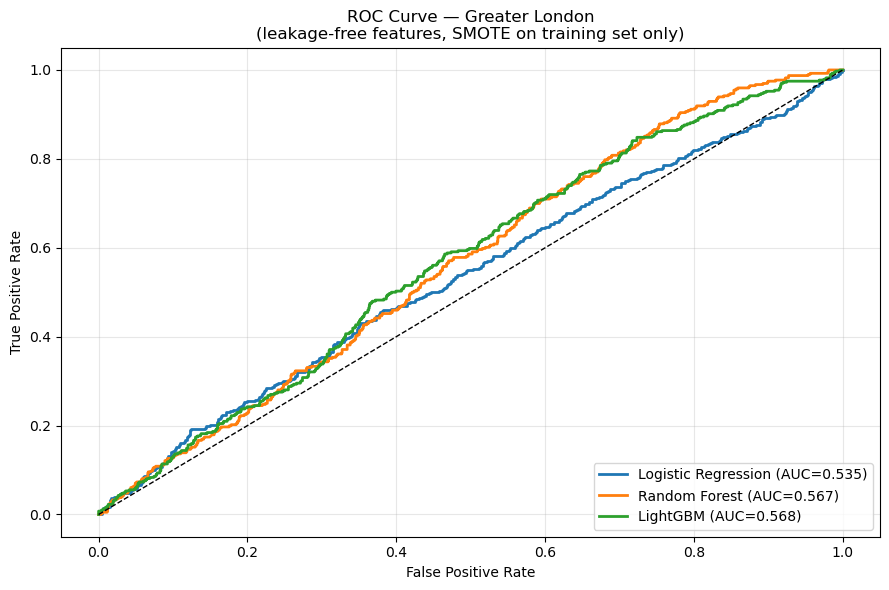

SHAP computed on 500 of 1878 test records


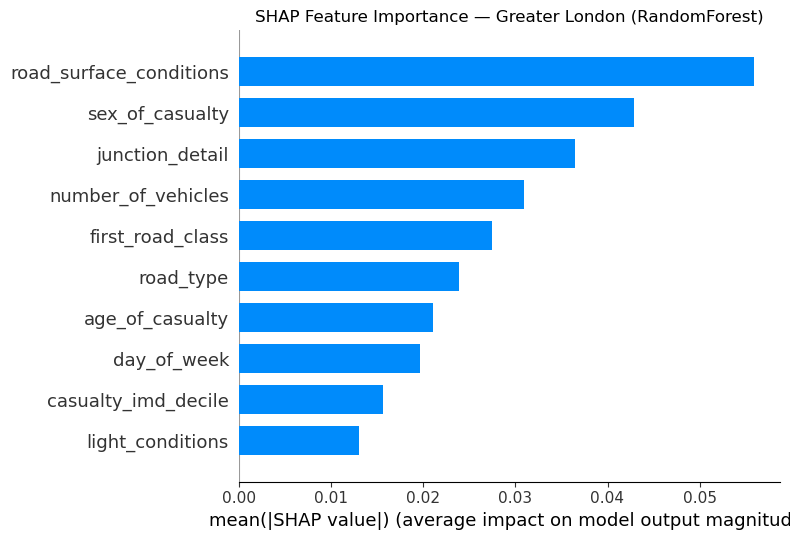

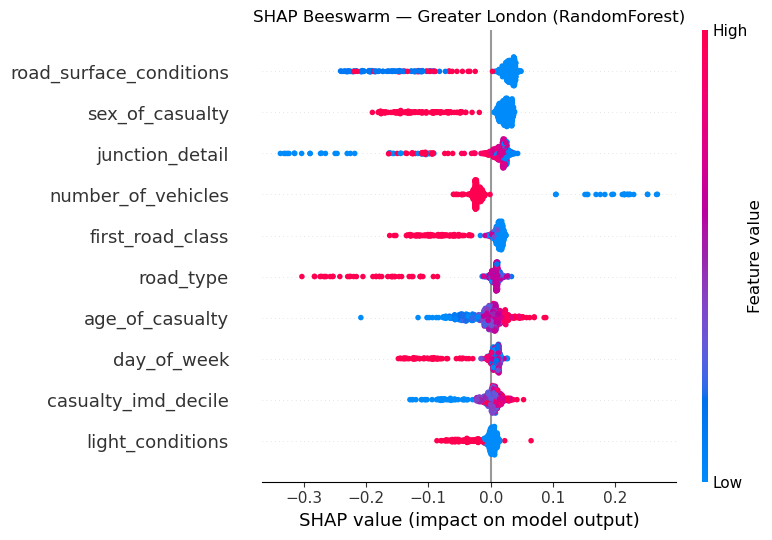

<Figure size 800x500 with 0 Axes>

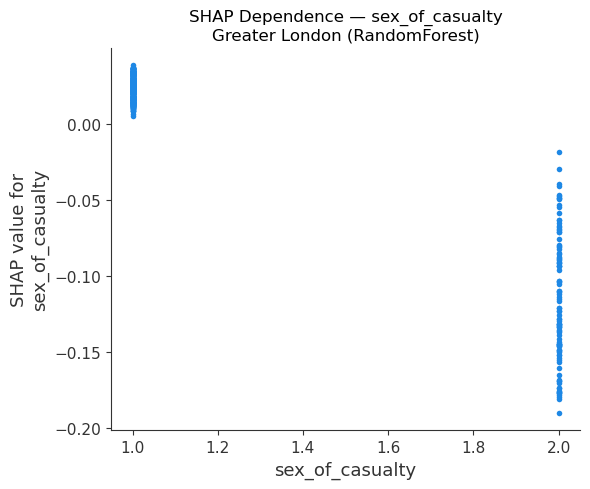

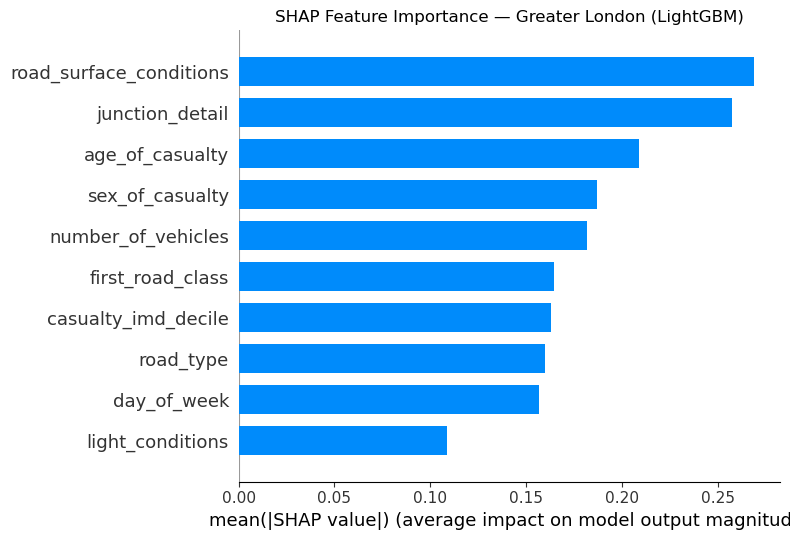

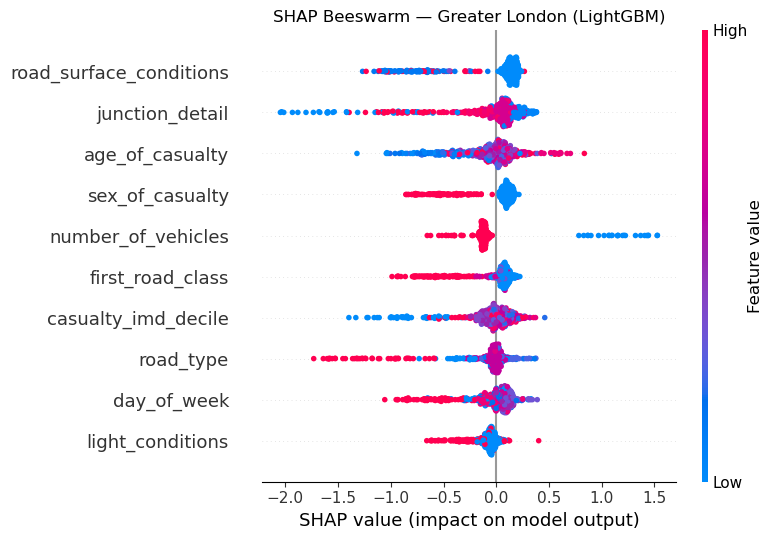

<Figure size 800x500 with 0 Axes>

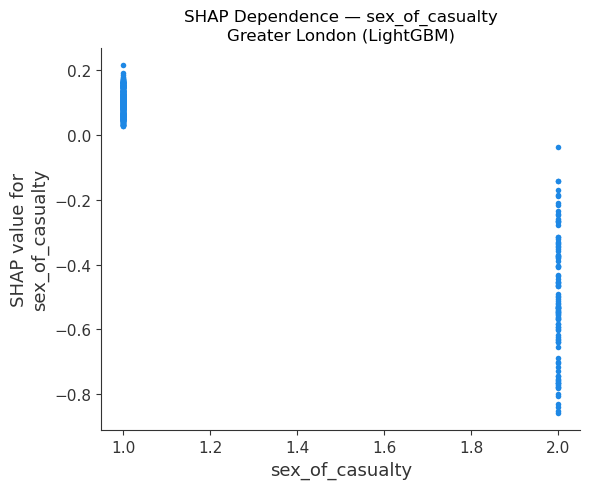


Greater London model performance:
              Model  Accuracy  Precision  Recall    F1   AUC        Eval
Logistic Regression     0.558      0.233   0.477 0.313 0.535 80/20 split
      Random Forest     0.589      0.241   0.442 0.312 0.567 80/20 split
           LightGBM     0.628      0.231   0.328 0.271 0.568 80/20 split

Greater Manchester
Removed sex_of_casualty == -1: 914 -> 873 (41 rows)
Sample size: 873;  serious/fatal share: 32.2%
n = 873 < 1000: 5-fold cross-validation.
  Logistic Regression: AUC=0.537±0.027
  Random Forest: AUC=0.530±0.027
  LightGBM: AUC=0.522±0.051


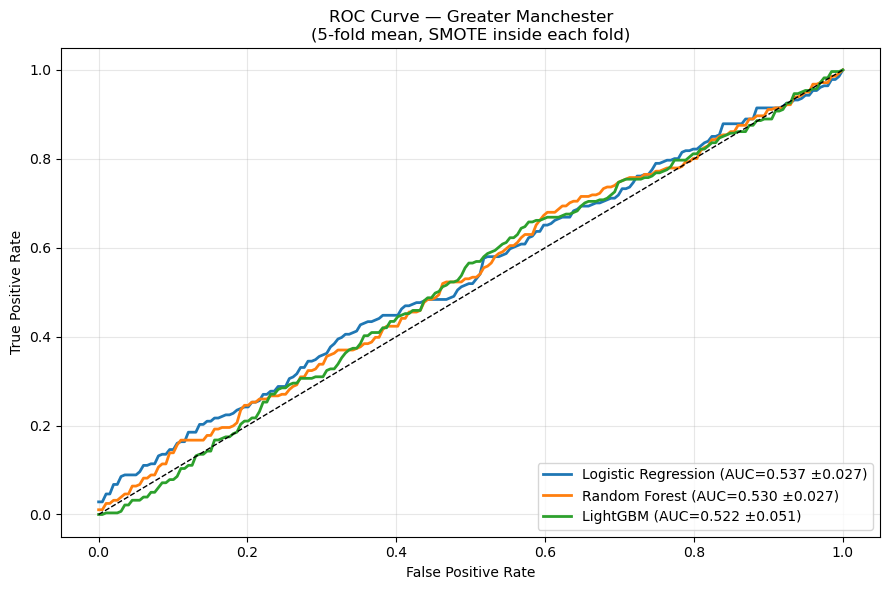

Greater Manchester: skipping SHAP (fold-level model instability makes a feature ranking non-reproducible at this sample size).

Greater Manchester model performance:
              Model     Accuracy    Precision       Recall           F1          AUC      Eval
Logistic Regression 0.535 ±0.030 0.345 ±0.025 0.491 ±0.048 0.404 ±0.028 0.537 ±0.027 5-fold CV
      Random Forest 0.578 ±0.024 0.338 ±0.024 0.321 ±0.070 0.325 ±0.040 0.530 ±0.027 5-fold CV
           LightGBM 0.585 ±0.034 0.343 ±0.055 0.313 ±0.050 0.327 ±0.051 0.522 ±0.051 5-fold CV

West Midlands
Removed sex_of_casualty == -1: 880 -> 863 (17 rows)
Sample size: 863;  serious/fatal share: 26.0%
n = 863 < 1000: 5-fold cross-validation.
  Logistic Regression: AUC=0.517±0.021
  Random Forest: AUC=0.575±0.011
  LightGBM: AUC=0.583±0.042


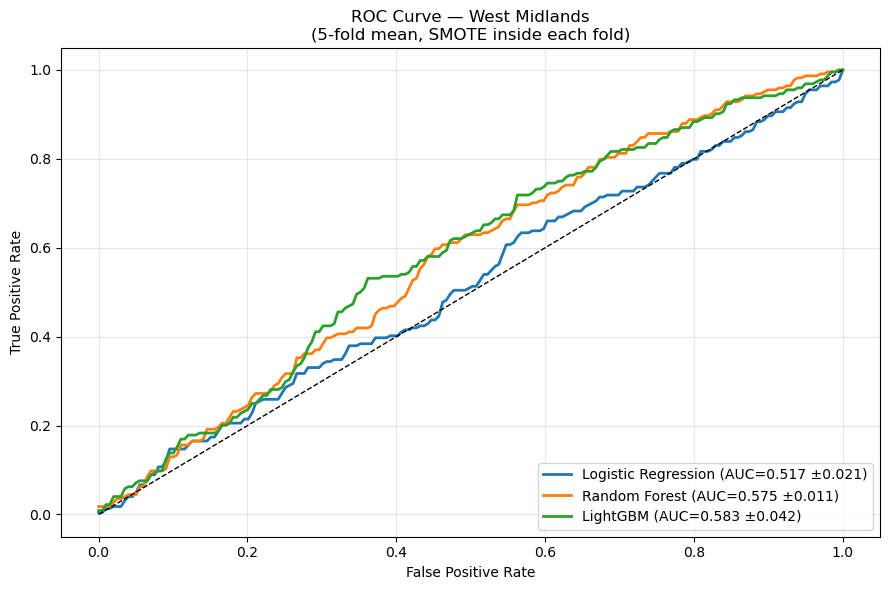

West Midlands: skipping SHAP (fold-level model instability makes a feature ranking non-reproducible at this sample size).

West Midlands model performance:
              Model     Accuracy    Precision       Recall           F1          AUC      Eval
Logistic Regression 0.531 ±0.014 0.266 ±0.019 0.469 ±0.088 0.339 ±0.038 0.517 ±0.021 5-fold CV
      Random Forest 0.616 ±0.026 0.295 ±0.015 0.344 ±0.063 0.315 ±0.030 0.575 ±0.011 5-fold CV
           LightGBM 0.644 ±0.015 0.292 ±0.046 0.268 ±0.067 0.278 ±0.056 0.583 ±0.042 5-fold CV


========== Model performance summary, three study regions ==========

--- Greater London ---
              Model  Accuracy  Precision  Recall    F1   AUC        Eval
Logistic Regression     0.558      0.233   0.477 0.313 0.535 80/20 split
      Random Forest     0.589      0.241   0.442 0.312 0.567 80/20 split
           LightGBM     0.628      0.231   0.328 0.271 0.568 80/20 split

--- Greater Manchester ---
              Model     Accuracy    Precision    

In [2]:
"""
Cell B — Cycling crash severity classification
==============================================
Produces Tables 5.2-5.4, Figures 5.7-5.9 (ROC) and Figures 5.10-5.12 (SHAP).

Changes from the earlier version:
1. All three regions use the Combined Authority extracts, so the modelling and
   the exposure analysis in Cell A cover the same geography.
2. The Random Forest grid search now wraps SMOTE and the classifier in an
   imbalanced-learn Pipeline, so oversampling happens inside each search fold.
   Previously the search was fitted to already-oversampled data, which let
   synthetic points derived from a validation record appear in that fold's
   training data and inflated the score used to select hyperparameters.
3. sex_of_casualty == -1 (the STATS19 "unknown" code) is filtered out so it is
   not encoded as a spurious category.
4. SHAP is run for Greater London only — a question of estimate stability, not
   of headline AUC: the London model is fitted on roughly 7,500 records whereas
   each fold in the smaller regions trains on roughly 700, with fold-level AUC
   standard deviations large enough that a feature ranking would not reproduce.
"""

import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------- configuration
REGION_FILES = {
    'Greater London':     'london_point.csv',
    'Greater Manchester': 'manchester_point.csv',
    'West Midlands':      'birmingham_point.csv',
}

SMALL_SAMPLE_THRESHOLD = 1000    # below this n, use 5-fold cross-validation

# Feature selection is a positive whitelist rather than an exclusion list: only
# the variables named here can enter the model, so every post-crash STATS19
# descriptor (pedestrian_movement, vehicle_leaving_carriageway,
# hit_object_in_carriageway, ...) is excluded by construction.
CANDIDATE_FEATURES = [
    'casualty_imd_decile',
    'speed_limit',
    'road_type',
    'junction_detail',
    'light_conditions',
    'weather_conditions',
    'road_surface_conditions',
    'day_of_week',
    'first_road_class',
    'age_of_casualty',
    'sex_of_casualty',
    'casualty_type',          # constant within a cyclist-only sample (zero variance)
    'pedestrian_location',    # not applicable to cyclist casualties (near-constant)
    'urban_or_rural_area',
    'number_of_vehicles',
    'number_of_casualties',
]

all_region_metrics = {}

for region, path in REGION_FILES.items():
    slug = region.lower().replace(' ', '_')
    print(f"\n{'='*60}\n{region}\n{'='*60}")

    df = pd.read_csv(path, low_memory=False)

    # ---------- target: STATS19 1 = Fatal, 2 = Serious, 3 = Slight ------------
    df['Y'] = np.where(df['collision_severity'] <= 2, 1, 0)

    # ---------- drop sex_of_casualty == -1 only -------------------------------
    # get_dummies encodes -1 as its own category, which produced extreme SHAP
    # values unlike either male or female. The -1 code is retained as a valid
    # "unknown" category for every other feature.
    if 'sex_of_casualty' in df.columns:
        before = len(df)
        df = df[df['sex_of_casualty'] != -1].reset_index(drop=True)
        print(f'Removed sex_of_casualty == -1: {before} -> {len(df)} '
              f'({before - len(df)} rows)')

    n_total = len(df)
    print(f'Sample size: {n_total};  serious/fatal share: {df["Y"].mean():.1%}')

    # ---------- encoding ------------------------------------------------------
    feature_cols = [c for c in CANDIDATE_FEATURES if c in df.columns]
    leak = [c for c in feature_cols if 'severity' in c.lower()]
    if leak:
        raise ValueError(f'Leakage guard tripped: {leak}')

    X = df[feature_cols].copy()
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    X[cat_cols] = X[cat_cols].astype(str)
    X_encoded = pd.get_dummies(X, drop_first=True)
    y = df['Y']

    use_cv = n_total < SMALL_SAMPLE_THRESHOLD

    # ══════════════════════════════════════════════════════════════════════
    # Small samples: 5-fold cross-validation
    # ══════════════════════════════════════════════════════════════════════
    if use_cv:
        print(f'n = {n_total} < {SMALL_SAMPLE_THRESHOLD}: 5-fold cross-validation.')
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # SMOTE inside each fold, so synthetic minority points are never derived
        # from records that end up in that fold's validation set.
        cv_pipelines = {
            'Logistic Regression': ImbPipeline([
                ('smote', SMOTE(random_state=42)),
                ('clf', LogisticRegression(max_iter=1000, random_state=42,
                                           class_weight='balanced'))]),
            'Random Forest': ImbPipeline([
                ('smote', SMOTE(random_state=42)),
                ('clf', RandomForestClassifier(n_estimators=100, max_depth=10,
                                               random_state=42,
                                               class_weight='balanced'))]),
            'LightGBM': ImbPipeline([
                ('smote', SMOTE(random_state=42)),
                ('clf', LGBMClassifier(random_state=42, verbose=-1,
                                       class_weight='balanced'))]),
        }
        scoring = {'accuracy': 'accuracy', 'precision': 'precision',
                   'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

        rows = []
        for name, pipe in cv_pipelines.items():
            res = cross_validate(pipe, X_encoded, y, cv=cv,
                                 scoring=scoring, n_jobs=-1)
            rows.append({
                'Model': name,
                'Accuracy':  f"{res['test_accuracy'].mean():.3f} ±{res['test_accuracy'].std():.3f}",
                'Precision': f"{res['test_precision'].mean():.3f} ±{res['test_precision'].std():.3f}",
                'Recall':    f"{res['test_recall'].mean():.3f} ±{res['test_recall'].std():.3f}",
                'F1':        f"{res['test_f1'].mean():.3f} ±{res['test_f1'].std():.3f}",
                'AUC':       f"{res['test_roc_auc'].mean():.3f} ±{res['test_roc_auc'].std():.3f}",
                'Eval': '5-fold CV',
            })
            print(f"  {name}: AUC={res['test_roc_auc'].mean():.3f}"
                  f"±{res['test_roc_auc'].std():.3f}")
        all_region_metrics[region] = pd.DataFrame(rows)

        # -- mean ROC across folds; same cv object, so folds match the table ---
        mean_fpr = np.linspace(0, 1, 200)
        model_specs = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42,
                                                      class_weight='balanced'),
            'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10,
                                                    random_state=42,
                                                    class_weight='balanced'),
            'LightGBM': LGBMClassifier(random_state=42, verbose=-1,
                                       class_weight='balanced'),
        }
        colors = {'Logistic Regression': '#1f77b4',
                  'Random Forest': '#ff7f0e',
                  'LightGBM': '#2ca02c'}
        splits = list(cv.split(X_encoded, y))

        plt.figure(figsize=(9, 6))
        for name, base_model in model_specs.items():
            tprs, fold_aucs = [], []
            for tr, te in splits:
                X_tr, y_tr = X_encoded.iloc[tr], y.iloc[tr]
                X_te, y_te = X_encoded.iloc[te], y.iloc[te]
                X_res, y_res = SMOTE(random_state=42).fit_resample(X_tr, y_tr)
                m = copy.deepcopy(base_model).fit(X_res, y_res)
                prob = m.predict_proba(X_te)[:, 1]
                f, t, _ = roc_curve(y_te, prob)
                fold_aucs.append(auc(f, t))
                tprs.append(np.interp(mean_fpr, f, t))
            plt.plot(mean_fpr, np.mean(tprs, axis=0), color=colors[name], linewidth=2,
                     label=f'{name} (AUC={np.mean(fold_aucs):.3f} ±{np.std(fold_aucs):.3f})')
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve — {region}\n(5-fold mean, SMOTE inside each fold)')
        plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f'{slug}_roc.png', dpi=300); plt.show()

        print(f'{region}: skipping SHAP (fold-level model instability makes a '
              f'feature ranking non-reproducible at this sample size).')

    # ══════════════════════════════════════════════════════════════════════
    # Large sample: single 80/20 split, plus SHAP
    # ══════════════════════════════════════════════════════════════════════
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded, y, test_size=0.2, random_state=42, stratify=y)
        print(f'80/20 split: {len(X_train)} train, {len(X_test)} test')

        # SMOTE fitted on the training partition only; the test set keeps its
        # natural class distribution.
        X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

        lr_model = LogisticRegression(max_iter=1000, random_state=42,
                                      class_weight='balanced').fit(X_train_res, y_train_res)
        lgb_model = LGBMClassifier(random_state=42, verbose=-1,
                                   class_weight='balanced').fit(X_train_res, y_train_res)

        # Random Forest tuning: SMOTE lives inside the pipeline, so it is applied
        # separately within each search fold and never leaks synthetic points from
        # a validation fold into its own training data. Fit on the RAW training
        # partition, not the pre-oversampled one.
        cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        rf_pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42, class_weight='balanced')),
        ])
        grid = GridSearchCV(
            rf_pipeline,
            {'clf__n_estimators': [100, 200], 'clf__max_depth': [10, 20, None]},
            cv=cv_strategy, scoring='roc_auc', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_rf = grid.best_estimator_          # a fitted ImbPipeline
        print(f'Random Forest best parameters: {grid.best_params_}')
        print(f'Random Forest best CV AUC: {grid.best_score_:.3f}')

        final_models = {'Logistic Regression': lr_model,
                        'Random Forest': best_rf,
                        'LightGBM': lgb_model}

        rows = []
        plt.figure(figsize=(9, 6))
        for name, model in final_models.items():
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]
            f, t, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(f, t)
            rows.append({
                'Model': name,
                'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
                'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
                'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 3),
                'F1':        round(f1_score(y_test, y_pred, zero_division=0), 3),
                'AUC':       round(roc_auc, 3),
                'Eval': '80/20 split',
            })
            plt.plot(f, t, label=f'{name} (AUC={roc_auc:.3f})', linewidth=2)
        all_region_metrics[region] = pd.DataFrame(rows)

        plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve — {region}\n'
                  f'(leakage-free features, SMOTE on training set only)')
        plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
        plt.savefig(f'{slug}_roc.png', dpi=300); plt.show()

        # ---- SHAP (Greater London only) --------------------------------------
        # Computed on a random subsample of up to 500 held-out test records to
        # keep TreeExplainer runtime manageable. The seed is fixed and the draw
        # ignores the outcome variable, so it is unbiased with respect to severity.
        X_shap = X_test.sample(min(500, len(X_test)), random_state=42)
        print(f'SHAP computed on {len(X_shap)} of {len(X_test)} test records')

        shap_models = {
            'RandomForest': best_rf.named_steps['clf'],   # unwrap the pipeline
            'LightGBM':     lgb_model,
        }
        for model_name, estimator in shap_models.items():
            try:
                explainer = shap.TreeExplainer(estimator)
                sv = explainer.shap_values(X_shap)
                # normalise the return shape across SHAP versions / model types
                if isinstance(sv, list):
                    sv = sv[1]
                elif isinstance(sv, np.ndarray) and sv.ndim == 3:
                    sv = sv[:, :, 1]

                plt.figure(figsize=(10, 6))
                shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=10)
                plt.title(f'SHAP Feature Importance — {region} ({model_name})')
                plt.tight_layout()
                plt.savefig(f'{slug}_shap_bar_{model_name.lower()}.png',
                            dpi=300, bbox_inches='tight')
                plt.show()

                plt.figure(figsize=(10, 6))
                shap.summary_plot(sv, X_shap, show=False, max_display=10)
                plt.title(f'SHAP Beeswarm — {region} ({model_name})')
                plt.tight_layout()
                plt.savefig(f'{slug}_shap_beeswarm_{model_name.lower()}.png',
                            dpi=300, bbox_inches='tight')
                plt.show()

                # Dependence plot for sex_of_casualty: fixes the direction of the
                # sex effect, which the beeswarm shows only as a colour gradient.
                sex_col = [c for c in X_shap.columns if 'sex_of_casualty' in c]
                if sex_col:
                    plt.figure(figsize=(8, 5))
                    shap.dependence_plot(sex_col[0], sv, X_shap,
                                         interaction_index=None, show=False)
                    plt.title(f'SHAP Dependence — sex_of_casualty\n{region} ({model_name})')
                    plt.tight_layout()
                    plt.savefig(f'{slug}_shap_dependence_sex_{model_name.lower()}.png',
                                dpi=300, bbox_inches='tight')
                    plt.show()

            except Exception as e:
                print(f'WARNING: SHAP failed ({region}/{model_name}): {e}')

    print(f'\n{region} model performance:')
    print(all_region_metrics[region].to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════
# Summary across the three study regions  (send this output for the write-up)
# ══════════════════════════════════════════════════════════════════════════
print('\n\n========== Model performance summary, three study regions ==========')
for region, metrics in all_region_metrics.items():
    print(f'\n--- {region} ---')
    print(metrics.to_string(index=False))

pd.concat([m.assign(Region=r) for r, m in all_region_metrics.items()]
          ).to_csv('tables_5_2_to_5_4_model_performance.csv', index=False)
print('\nSaved: tables_5_2_to_5_4_model_performance.csv')

In [3]:
# ============================================================================
# Diagnostic: is the road_surface_conditions SHAP effect monotonic?
# Run this as a new cell AFTER Cell B has finished. It reuses `sv` (the SHAP
# values of the last model explained, i.e. Greater London LightGBM) and
# `X_shap` (the 500-record subsample) that Cell B leaves in memory.
# ============================================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

FEATURE = 'road_surface_conditions'

# STATS19 code book for this field
LABELS = {
    -1: 'Data missing / out of range',
     1: 'Dry',
     2: 'Wet or damp',
     3: 'Snow',
     4: 'Frost or ice',
     5: 'Flood over 3cm deep',
     6: 'Oil or diesel',
     7: 'Mud',
     9: 'Unknown (self-reported)',
}

# ---- locate the feature column -------------------------------------------
if FEATURE in X_shap.columns:
    col = FEATURE
    idx = list(X_shap.columns).index(col)
    vals = X_shap[col].values
    shap_vals = sv[:, idx]
else:
    # fell through one-hot encoding: aggregate the dummy columns back
    dummies = [c for c in X_shap.columns if c.startswith(FEATURE)]
    if not dummies:
        raise KeyError(f'{FEATURE} not found in X_shap. Columns: {list(X_shap.columns)[:30]}')
    print(f'NOTE: {FEATURE} was one-hot encoded into {len(dummies)} columns; '
          f'reporting each dummy separately.\n')
    for c in dummies:
        i = list(X_shap.columns).index(c)
        present = X_shap[c].astype(bool).values
        print(f'  {c:<45} present n={present.sum():>4}  '
              f'mean SHAP when present = {sv[present, i].mean():+.4f}')
    raise SystemExit

# ---- mean SHAP by raw code -----------------------------------------------
df = pd.DataFrame({'code': vals, 'shap': shap_vals})
g = df.groupby('code')['shap'].agg(n='size', mean_shap='mean', sd='std').reset_index()
g['label'] = g['code'].map(LABELS).fillna('(unlabelled code)')
g['share_%'] = g['n'] / len(df) * 100

print(f'SHAP contribution of {FEATURE}, by STATS19 code')
print(f'(Greater London LightGBM, {len(df)} held-out records)\n')
print(g[['code', 'label', 'n', 'share_%', 'mean_shap', 'sd']]
      .to_string(index=False,
                 formatters={'share_%': '{:.1f}'.format,
                             'mean_shap': '{:+.4f}'.format,
                             'sd': '{:.4f}'.format}))

# ---- verdict --------------------------------------------------------------
real = g[g['code'] > 0]                       # drop the -1 missing category
adverse = real[real['code'] >= 2]['shap' if False else 'mean_shap']
dry = real[real['code'] == 1]['mean_shap']

print('\n' + '-' * 70)
if len(real) > 2:
    rho, p = spearmanr(real['code'], real['mean_shap'])
    print(f'Spearman(code, mean SHAP) over valid codes only: {rho:+.3f}  p = {p:.3f}')

if len(dry) and len(adverse):
    # weight adverse codes by how many records carry them
    w = real[real['code'] >= 2]
    adverse_mean = np.average(w['mean_shap'], weights=w['n']) if len(w) else np.nan
    print(f'Dry (code 1)      : mean SHAP = {dry.iloc[0]:+.4f}')
    print(f'Adverse (codes 2+): mean SHAP = {adverse_mean:+.4f}  '
          f'(n = {int(w["n"].sum())})')
    gap = adverse_mean - dry.iloc[0]
    print(f'Adverse minus dry : {gap:+.4f}')
    print()
    if gap > 0.05:
        print('VERDICT: adverse surfaces push predictions TOWARDS serious injury.')
        print('  -> the original strong claim is supported; tell Claude to restore it.')
    elif gap < -0.05:
        print('VERDICT: adverse surfaces push predictions AWAY from serious injury.')
        print('  -> the effect is real but runs opposite to the original claim.')
    else:
        print('VERDICT: no clear directional effect once codes are averaged.')
        print('  -> the conservative wording currently in the dissertation is correct.')
print('-' * 70)
print('\nAlso check the sd column: if it is large relative to the gap, the')
print('feature is inconsistent within codes and no directional claim is safe.')

SHAP contribution of road_surface_conditions, by STATS19 code
(Greater London LightGBM, 500 held-out records)

 code                   label   n share_% mean_shap     sd
    1                     Dry 395    79.0   +0.1440 0.0428
    2             Wet or damp  75    15.0   -0.7982 0.2199
    4            Frost or ice   2     0.4   -0.3502 0.1350
    9 Unknown (self-reported)  28     5.6   -0.5809 0.3730

----------------------------------------------------------------------
Spearman(code, mean SHAP) over valid codes only: -0.400  p = 0.600
Dry (code 1)      : mean SHAP = +0.1440
Adverse (codes 2+): mean SHAP = -0.7317  (n = 105)
Adverse minus dry : -0.8757

VERDICT: adverse surfaces push predictions AWAY from serious injury.
  -> the effect is real but runs opposite to the original claim.
----------------------------------------------------------------------

Also check the sd column: if it is large relative to the gap, the
feature is inconsistent within codes and no directional claim i